# JobFit — Phase 3 : Score ML supervisé

Feature engineering + entraînement de modèles + tracking MLflow.

In [11]:
import sys, os

# Chemins absolus
base = os.path.expanduser("~/WORKSPACE /PROJETS FIN FORMATION JEDHA/NOUVEAU TAFF/jobfit_phase2")
sys.path.insert(0, os.path.join(base, 'src/ml'))
sys.path.insert(0, os.path.join(base, 'src/nlp'))
sys.path.insert(0, os.path.join(base, 'src/api'))

import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from cv_parser  import parse_cv
from embeddings import EmbeddingEngine
from scorer     import build_features, generate_pseudo_labels, train_scorer, score_offres

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)
os.makedirs('../mlruns', exist_ok=True)

DATA_DIR = os.path.join(base, 'data/processed')
CV_PATH = os.path.join(base, 'data/cv/sample_cv.pdf')
MODELS_DIR = '../models'

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup OK.')

Setup OK.


## 1. Chargement CV + offres + embeddings

In [12]:
# CV
cv_data = parse_cv(CV_PATH)
engine  = EmbeddingEngine()
cv_embedding = engine.embed_text(cv_data['enriched_text'])
print(f'CV : {cv_data["nb_competences"]} compétences')

# Offres
conn      = sqlite3.connect(f'{DATA_DIR}/jobfit.db')
df_offres = pd.read_sql('SELECT * FROM offres', conn)
conn.close()
print(f'Offres : {len(df_offres)}')

# Embeddings pré-calculés
offres_embeddings = np.load(f'{DATA_DIR}/offres_embeddings.npy')
print(f'Embeddings shape : {offres_embeddings.shape}')

Parsing du CV : /Users/martialbayom/WORKSPACE /PROJETS FIN FORMATION JEDHA/NOUVEAU TAFF/jobfit_phase2/data/cv/sample_cv.pdf
  Titre          : DATA SCIENTIST - MACHINE LEARNING ENGINEER
  Compétences    : 47 trouvées
  Expérience     : 0 ans
  Formations     : 4
Chargement du modèle : paraphrase-multilingual-MiniLM-L12-v2


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8757.20it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé.
CV : 47 compétences
Offres : 6014
Embeddings shape : (6014, 384)


## 2. Feature engineering

In [13]:
print('Construction des features...')
features_df = build_features(cv_data, df_offres, cv_embedding, offres_embeddings)
print(f'Shape features : {features_df.shape}')
features_df.describe().round(3)

Construction des features...
Shape features : (6014, 7)


,cosine_similarity,skill_overlap_count,skill_overlap_ratio,skill_overlap_log,jaccard_similarity,offre_length_norm,cv_words_in_offre
count,6014.000,6014.000,6014.000,6014.000,6014.000,6014.000,6014.000
mean,0.248,0.380,0.008,0.176,0.010,0.820,0.038
std,0.117,1.163,0.025,0.442,0.006,0.242,0.025
min,-0.126,0.000,0.000,0.000,0.000,0.061,0.000
25%,0.173,0.000,0.000,0.000,0.006,0.672,0.033
50%,0.237,0.000,0.000,0.000,0.009,0.998,0.033
75%,0.311,0.000,0.000,0.000,0.012,1.000,0.049
max,0.735,15.000,0.319,2.773,0.089,1.000,0.262


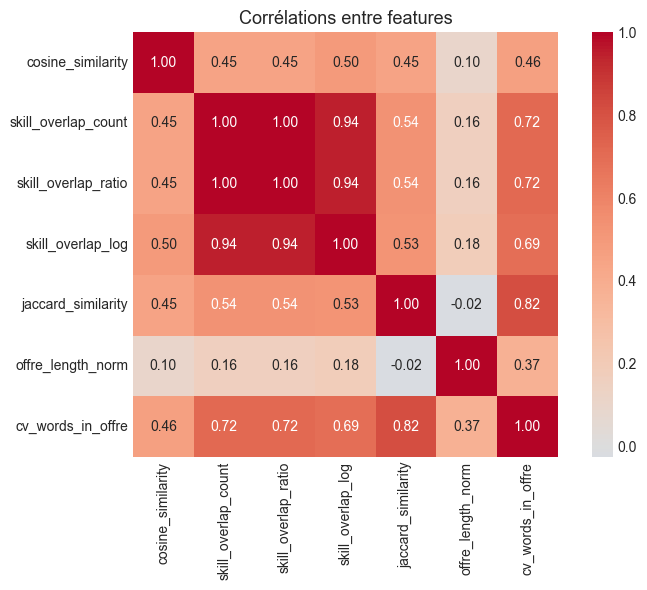

In [14]:
# Visualiser les corrélations entre features
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(features_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True)
ax.set_title('Corrélations entre features', fontsize=13)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/features_correlation.png', dpi=150)
plt.show()

## 3. Génération des pseudo-labels

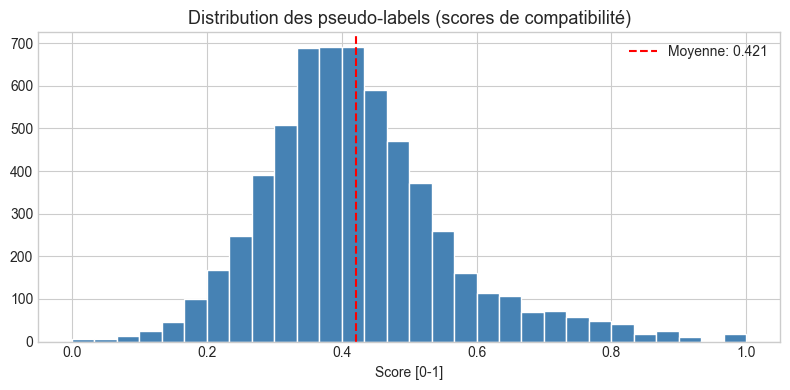

Labels — min: 0.000 | max: 1.000 | mean: 0.421


In [15]:
labels = generate_pseudo_labels(features_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(labels, bins=30, color='steelblue', edgecolor='white')
ax.axvline(labels.mean(), color='red', linestyle='--', label=f'Moyenne: {labels.mean():.3f}')
ax.set_title('Distribution des pseudo-labels (scores de compatibilité)', fontsize=13)
ax.set_xlabel('Score [0-1]')
ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/labels_distribution.png', dpi=150)
plt.show()

print(f'Labels — min: {labels.min():.3f} | max: {labels.max():.3f} | mean: {labels.mean():.3f}')

## 4. Entraînement des modèles + tracking MLflow

In [16]:
import mlflow
mlflow.set_tracking_uri('../mlruns')

import sys
sys.path.insert(0, '..')
import os
os.environ['MODELS_DIR']            = '../models'
os.environ['MLFLOW_TRACKING_URI']   = '../mlruns'

print('Entraînement des modèles (Ridge / RandomForest / GradientBoosting)...')
print('Résultats cross-validation 5-fold :\n')
best_model, results = train_scorer(features_df, labels, experiment_name='jobfit_scoring')

print('\nRésumé :')
pd.DataFrame(results).T

2026/04/02 16:35:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 16:35:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Entraînement des modèles (Ridge / RandomForest / GradientBoosting)...
Résultats cross-validation 5-fold :

  ridge                     R² CV: 1.0000 ± 0.0000  RMSE: 0.0000


2026/04/02 16:36:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 16:36:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  random_forest             R² CV: 0.9991 ± 0.0003  RMSE: 0.0015


2026/04/02 16:36:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/02 16:36:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  gradient_boosting         R² CV: 0.9994 ± 0.0001  RMSE: 0.0027

Meilleur modèle : ridge (R²=1.0000)
Modèle sauvegardé : ./models/best_scorer.pkl

Résumé :


,r2_cv_mean,r2_cv_std,rmse
ridge,1.0000,0.0000,0.0000
random_forest,0.9991,0.0003,0.0015
gradient_boosting,0.9994,0.0001,0.0027


## 5. Scoring final + analyse

In [17]:
df_scored = score_offres(best_model, features_df, df_offres)

print('--- TOP 15 OFFRES (score ML) ---')
cols = ['intitule', 'entreprise', 'lieu', 'type_contrat', 'ml_score_pct']
df_scored[cols].head(15)

--- TOP 15 OFFRES (score ML) ---


,intitule,entreprise,lieu,type_contrat,ml_score_pct
52,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,100.0
50,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,100.0
63,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,100.0
54,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,100.0
59,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,100.0
46,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,100.0
56,ALTERNANCE - Data Scientist H/F,,92 - Boulogne-Billancourt,CDD,100.0
303,Data Engineer spécialisé Machine Learning (F/H),GIO Recrutement Biarritz,76 - Rouen,CDI,99.5
44,DEEP - Data Scientist (H/F),,Luxembourg,CDI,98.3
64,Annonce générique - APPRENTISSAGE – Data Scien...,,78 - Versailles,CDD,97.8


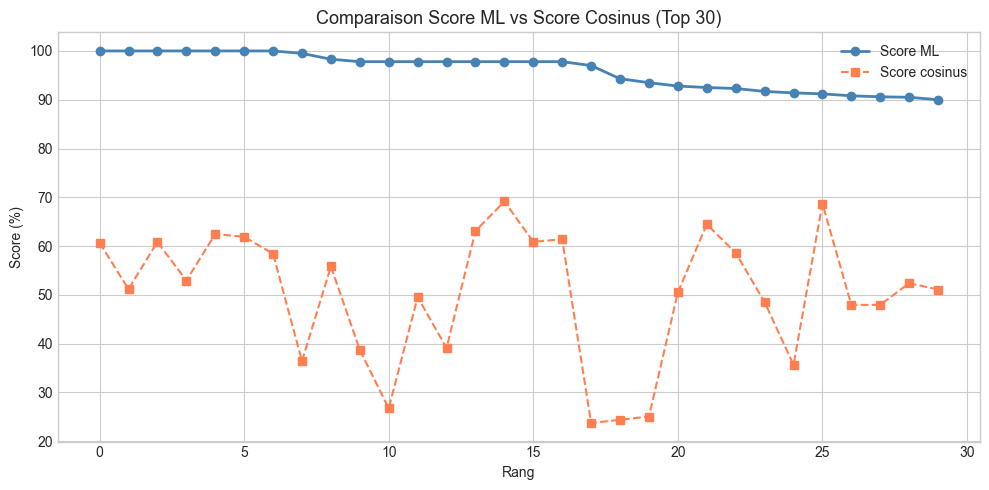

In [18]:
# Comparaison score cosinus vs score ML
df_compare = df_scored.copy()
df_compare['cosine_score_pct'] = (features_df['cosine_similarity'].values * 100)
df_compare = df_compare.sort_values('ml_score_pct', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df_compare))
ax.plot(x, df_compare['ml_score_pct'].values,    'o-', label='Score ML',     color='steelblue', linewidth=2)
ax.plot(x, df_compare['cosine_score_pct'].values, 's--', label='Score cosinus', color='coral',     linewidth=1.5)
ax.set_title('Comparaison Score ML vs Score Cosinus (Top 30)', fontsize=13)
ax.set_xlabel('Rang')
ax.set_ylabel('Score (%)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/ml_vs_cosine.png', dpi=150)
plt.show()

In [19]:
# Feature importance (si GradientBoosting ou RandomForest)
from sklearn.pipeline import Pipeline

model_step = best_model.named_steps['model']
if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    feat_names  = features_df.columns.tolist()

    fig, ax = plt.subplots(figsize=(8, 4))
    sorted_idx = np.argsort(importances)
    ax.barh([feat_names[i] for i in sorted_idx], importances[sorted_idx], color='teal')
    ax.set_title('Importance des features', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{DATA_DIR}/feature_importance.png', dpi=150)
    plt.show()
else:
    print('Feature importance non disponible pour ce modèle (Ridge).')

Feature importance non disponible pour ce modèle (Ridge).


In [20]:
# Sauvegarder
df_scored.to_csv(f'{DATA_DIR}/offres_ml_scored.csv', index=False)
np.save(f'{DATA_DIR}/features.npy', features_df.values)
print('Fichiers sauvegardés.')
print(f'  {DATA_DIR}/offres_ml_scored.csv')
print(f'  {DATA_DIR}/features.npy')
print(f'  ../models/best_scorer.pkl')
print('\nPour visualiser MLflow :')
print('  cd jobfit_phase0 && mlflow ui --backend-store-uri mlruns')
print('  Ouvrir http://localhost:5000')

Fichiers sauvegardés.
  /Users/martialbayom/WORKSPACE /PROJETS FIN FORMATION JEDHA/NOUVEAU TAFF/jobfit_phase2/data/processed/offres_ml_scored.csv
  /Users/martialbayom/WORKSPACE /PROJETS FIN FORMATION JEDHA/NOUVEAU TAFF/jobfit_phase2/data/processed/features.npy
  ../models/best_scorer.pkl

Pour visualiser MLflow :
  cd jobfit_phase0 && mlflow ui --backend-store-uri mlruns
  Ouvrir http://localhost:5000
